# Espectro en frecuencia de las señales

Analizamos las cuatro señales disponibles usando la columna `Flow`. Para cada archivo observamos la señal en el tiempo y su espectro de frecuencia.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'test' else Path.cwd()
DATA_DIR = ROOT / 'datos'
FS = 256  # Hz

archivos = sorted(DATA_DIR.glob('Mini TP Signals *.txt'))
archivos

[PosixPath('/Users/belu/Desktop/Ventilacion_desafios/datos/Mini TP Signals A.txt'),
 PosixPath('/Users/belu/Desktop/Ventilacion_desafios/datos/Mini TP Signals B.txt'),
 PosixPath('/Users/belu/Desktop/Ventilacion_desafios/datos/Mini TP Signals C.txt'),
 PosixPath('/Users/belu/Desktop/Ventilacion_desafios/datos/Mini TP Signals D.txt')]

## Carga y resumen

Los tiempos de los archivos pueden continuar una grabación concatenada. Para comparar cada archivo individualmente, el tiempo relativo se calcula restando el primer tiempo de cada señal.

In [2]:
señales = {}
resumen = []

for archivo in archivos:
    datos = pd.read_csv(archivo, sep='\t', skiprows=5)
    datos = datos[['Time', 'Flow']].dropna().copy()
    datos['Time relative'] = datos['Time'] - datos['Time'].iloc[0]
    señales[archivo.stem] = datos
    resumen.append({
        'archivo': archivo.name,
        'muestras': len(datos),
        'inicio original (s)': datos['Time'].iloc[0],
        'fin original (s)': datos['Time'].iloc[-1],
        'duración (s)': datos['Time relative'].iloc[-1],
    })

pd.DataFrame(resumen)

,archivo,muestras,inicio original (s),fin original (s),duración (s)
0,Mini TP Signals A.txt,209920,0.003906,820.000000,819.996094
1,Mini TP Signals B.txt,140800,820.000000,1369.996094,549.996094
2,Mini TP Signals C.txt,30208,1377.000000,1494.996094,117.996094
3,Mini TP Signals D.txt,431596,1512.000000,3197.917969,1685.917969


pareciera que son todas continuas! una atras de la otra

## FFT de cada señal

La FFT transforma la señal del tiempo al dominio de frecuencias. Un pico indica que una frecuencia aparece con mayor fuerza en la señal. En señales respiratorias, los componentes principales suelen estar en frecuencias bajas.

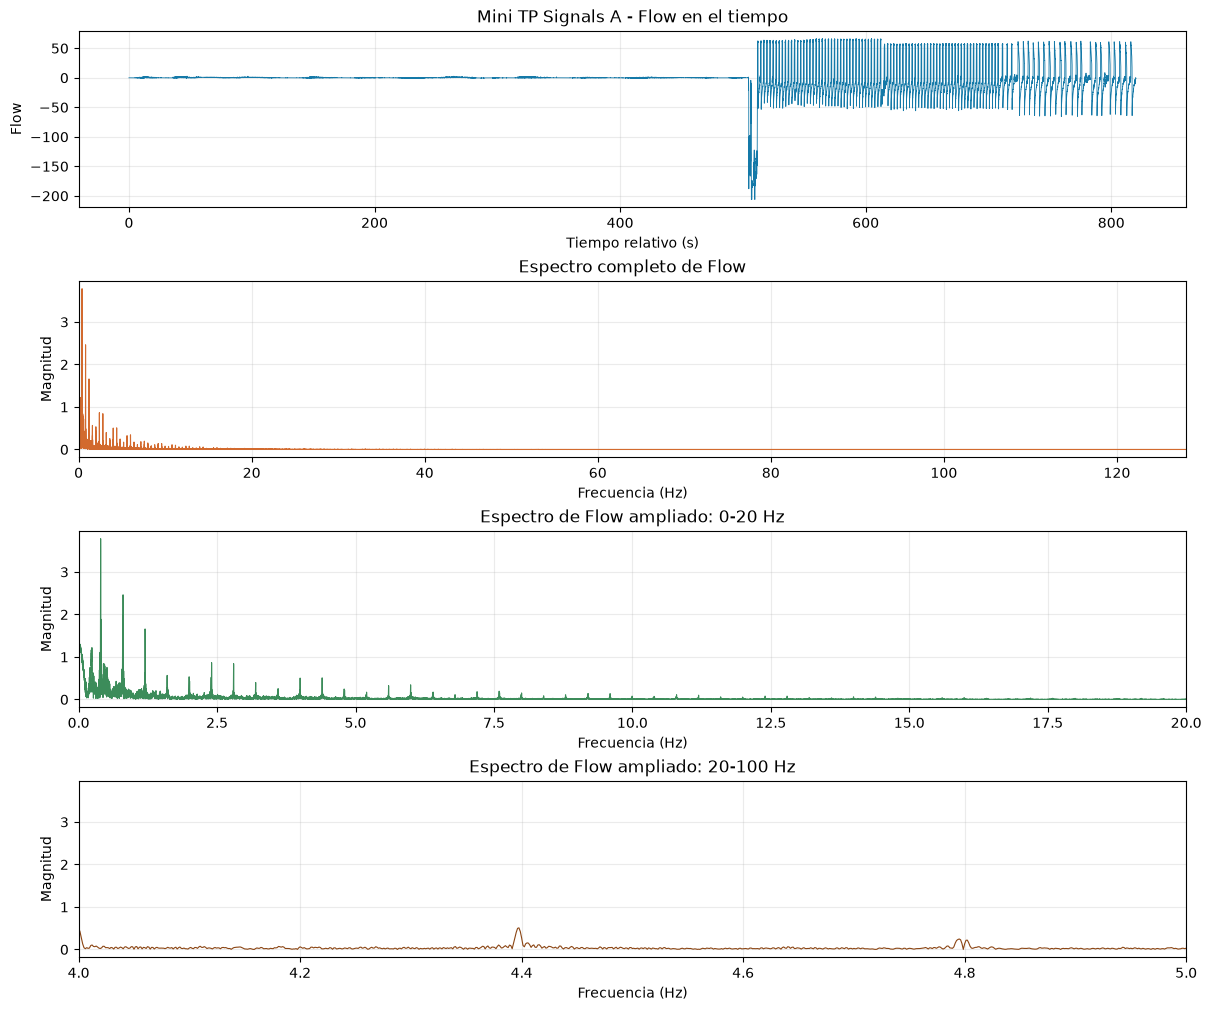

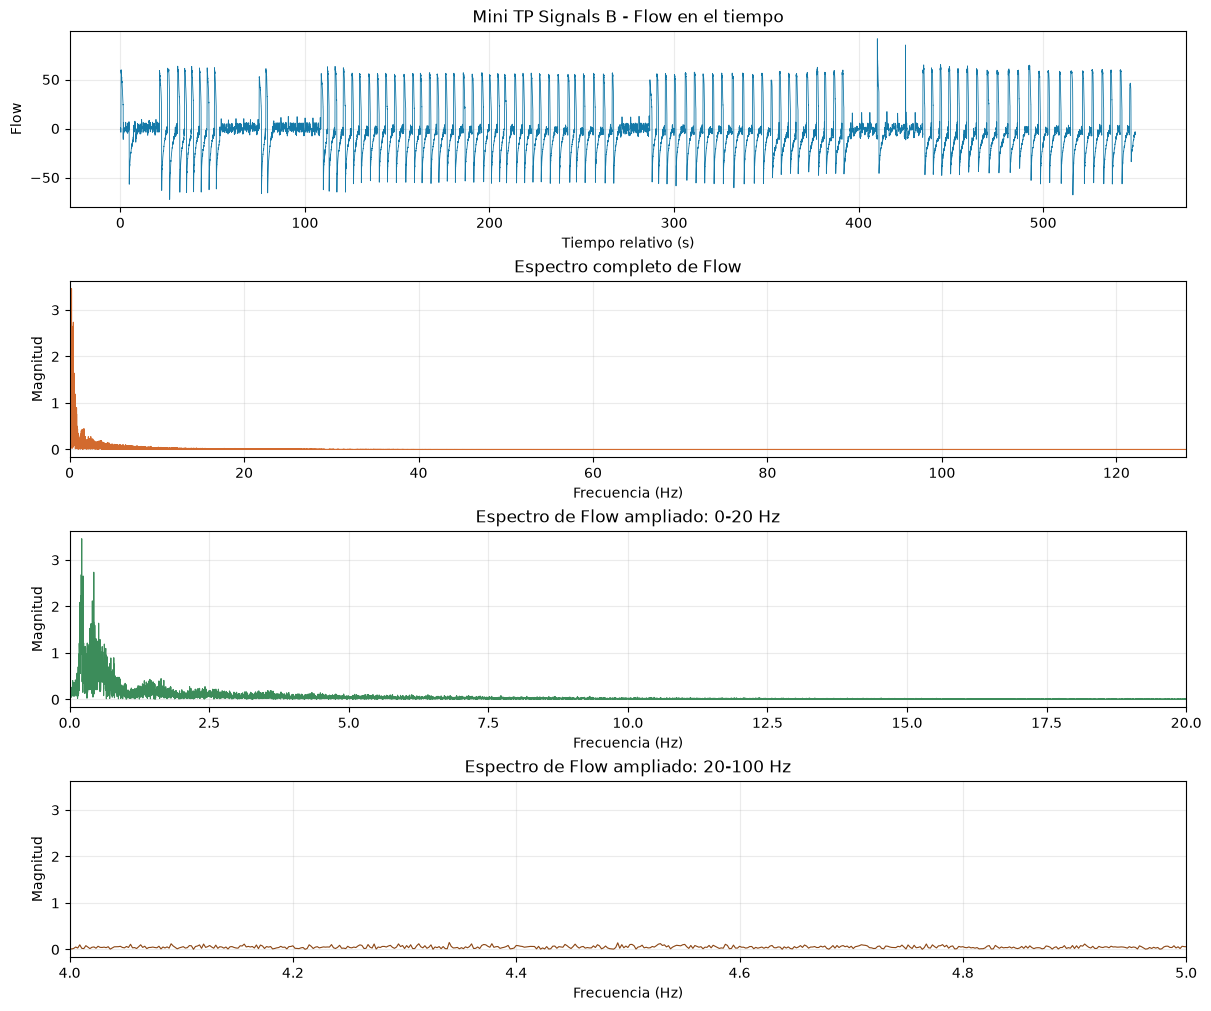

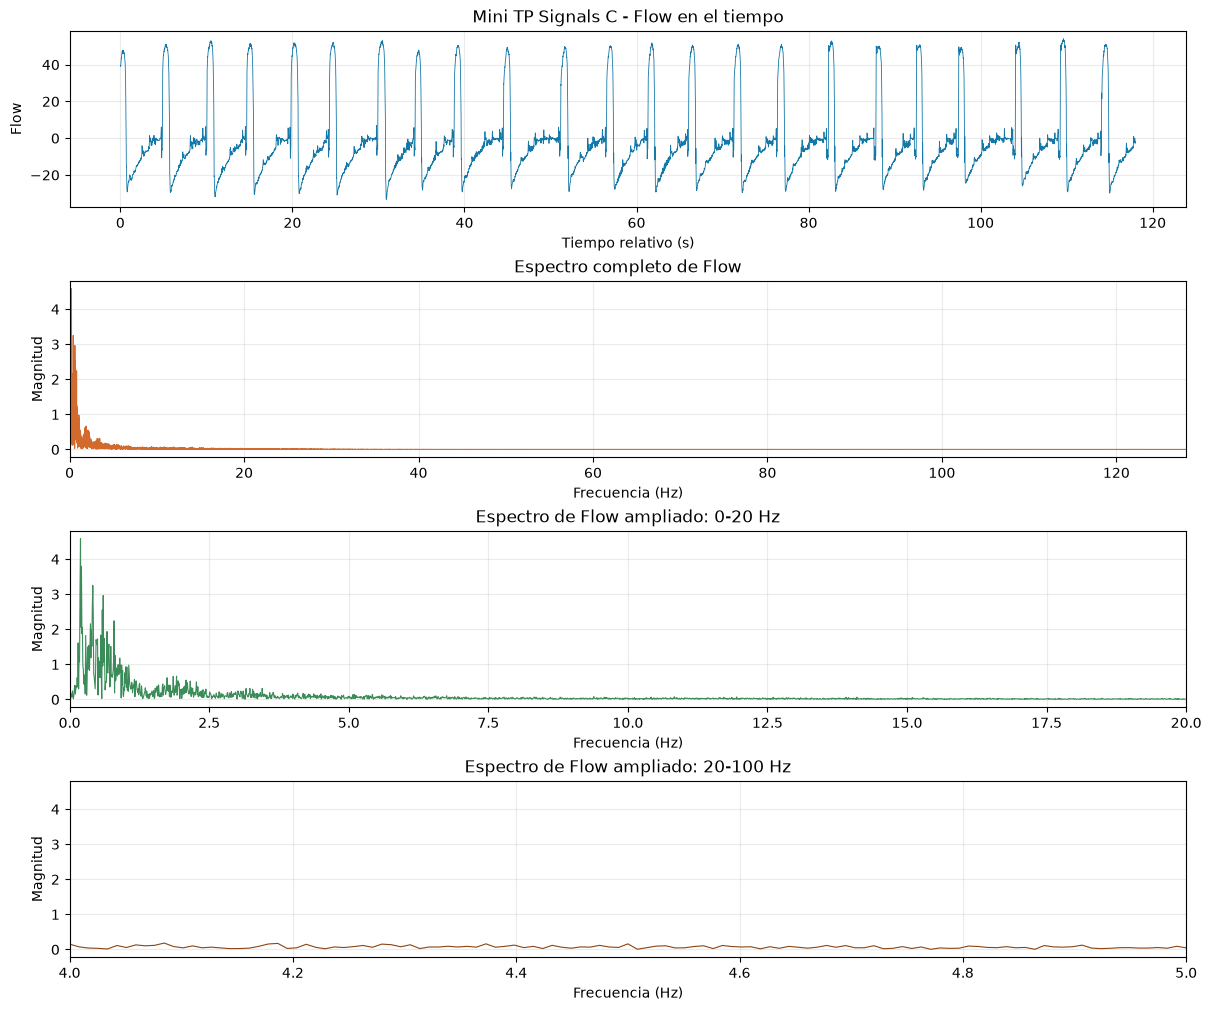

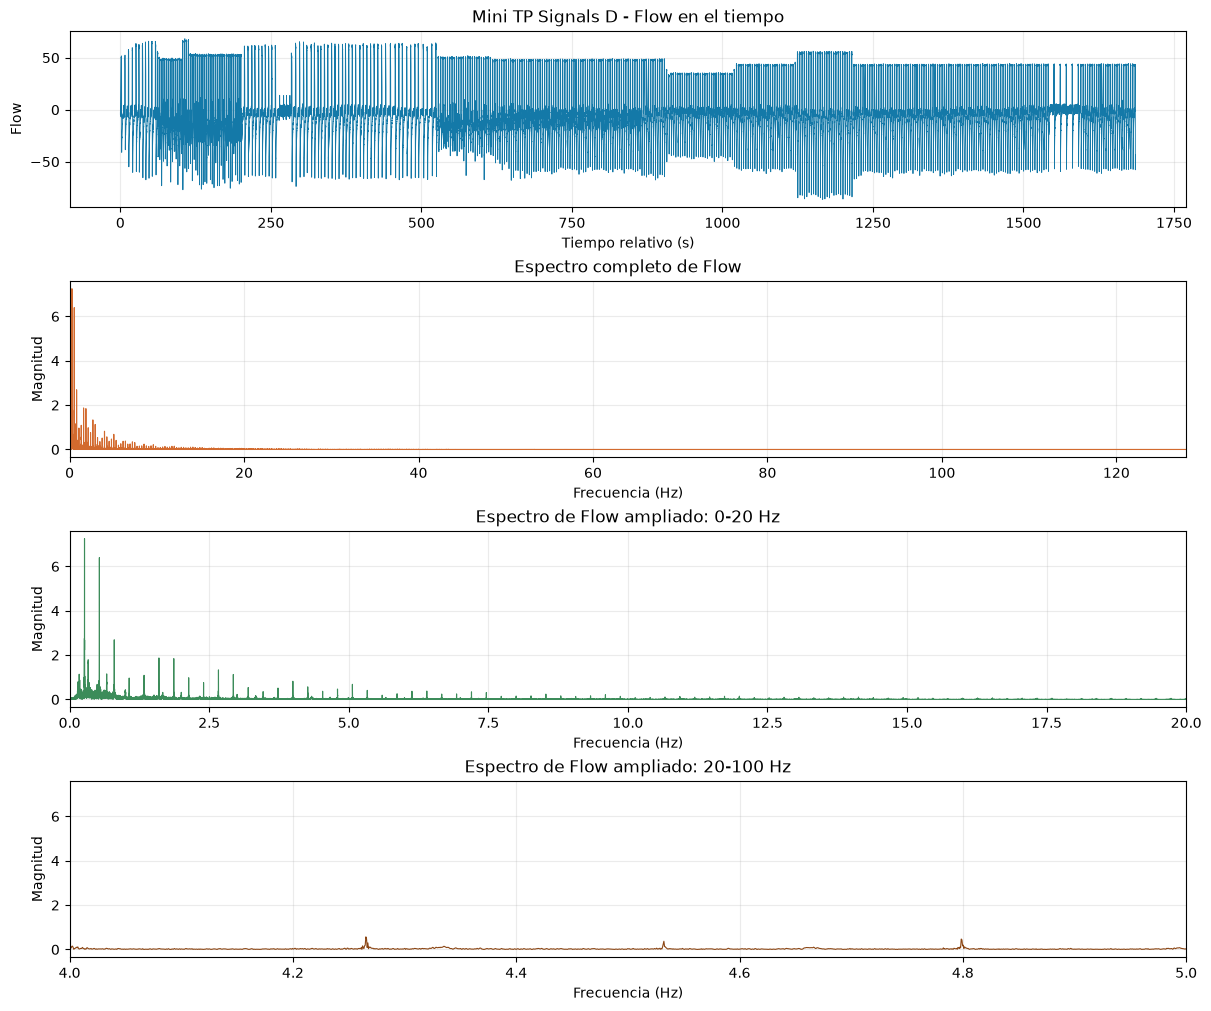

In [10]:
espectros = {}

for nombre, datos in señales.items():
    valores = datos['Flow'].to_numpy(dtype=float)
    valores = valores - valores.mean()
    n = len(valores)

    frecuencias = np.fft.rfftfreq(n, d=1 / FS)
    magnitud = np.abs(np.fft.rfft(valores)) / n
    espectros[nombre] = (frecuencias, magnitud)

    figura, ejes = plt.subplots(4, 1, figsize=(12, 10), constrained_layout=True)

    # Señal en el dominio del tiempo.
    ejes[0].plot(
        datos['Time relative'],
        datos['Flow'],
        linewidth=0.6,
        color='#1479a8'
    )
    ejes[0].set_title(f'{nombre} - Flow en el tiempo')
    ejes[0].set_xlabel('Tiempo relativo (s)')
    ejes[0].set_ylabel('Flow')
    ejes[0].grid(alpha=0.25)

    # Espectro completo: desde 0 hasta la frecuencia de Nyquist.
    ejes[1].plot(frecuencias, magnitud, linewidth=0.8, color='#d26a2e')
    ejes[1].set_xlim(0, FS / 2)
    ejes[1].set_title('Espectro completo de Flow')
    ejes[1].set_xlabel('Frecuencia (Hz)')
    ejes[1].set_ylabel('Magnitud')
    ejes[1].grid(alpha=0.25)

    # Zoom de bajas frecuencias para observar respiración y ruido lento.
    ejes[2].plot(frecuencias, magnitud, linewidth=0.8, color='#3c8c5a')
    ejes[2].set_xlim(0, 20)
    ejes[2].set_title('Espectro de Flow ampliado: 0-20 Hz')
    ejes[2].set_xlabel('Frecuencia (Hz)')
    ejes[2].set_ylabel('Magnitud')
    ejes[2].grid(alpha=0.25)

    # quiero hacer zoom para intentar medir distancia de picos sobretodo en la señal A y D
    ejes[3].plot(frecuencias, magnitud, linewidth=0.8, color='#8b4513')
    ejes[3].set_xlim(4, 5)
    ejes[3].set_title('Espectro de Flow ampliado: 20-100 Hz')
    ejes[3].set_xlabel('Frecuencia (Hz)')
    ejes[3].set_ylabel('Magnitud')
    ejes[3].grid(alpha=0.25)

    plt.show()

## Pruebas de tipos de respiracion